# Week 4 Controlled VLM Architecture Comparison

Two reference-listed VLM architectures are evaluated on the same 20 public-image scenarios under clean, deterministic Gaussian-noise, and brightness-0.60 conditions. The frozen 60-row image bank, prompt, seed, generation policy, rubric, and local Llama Judge are held constant; only the architecture and its native processor/chat template change.

All quality scores are AI-assisted diagnostics, not human ground truth or deployed InGen product performance.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'W04_Multimodal_Architecture_Comparison_v0.2.0.json').exists():
    ROOT = ROOT / 'phase_b_evaluation'

comparison = json.loads(
    (ROOT / 'W04_Multimodal_Architecture_Comparison_v0.2.0.json').read_text(encoding='utf-8')
)
performance = json.loads(
    (ROOT / 'W04_System_Performance_Summary_v0.2.0.json').read_text(encoding='utf-8')
)

assert comparison['controlled_inputs']['matched_request_count_per_model'] == 60
assert comparison['judge_control']['status'] == 'matched'
assert len(comparison['models']) == 2
print('Matched requests per VLM:', comparison['controlled_inputs']['matched_request_count_per_model'])
print('Judge control:', comparison['judge_control']['status'])

Matched requests per VLM: 60
Judge control: matched


In [2]:
condition_rows = []
robustness_rows = []
for model in comparison['models']:
    model_key = model['model_key']
    for row in model['quality']['conditions']:
        condition_rows.append({'model': model_key, **row})
    for row in model['quality']['perturbation_robustness']:
        robustness_rows.append({'model': model_key, **row})

condition_df = pd.DataFrame(condition_rows)
robustness_df = pd.DataFrame(robustness_rows)
display(condition_df[[
    'model', 'condition_id', 'parsed_row_count', 'mean_total_score',
    'mean_scene_interpretation', 'mean_decision_recommendation',
    'mean_uncertainty_and_claim_control', 'acceptable_decision_rate',
    'forbidden_claim_rate'
]])
display(robustness_df[[
    'model', 'condition_id', 'mean_clean_to_perturbed_score_drop',
    'decision_consistency_clean_vs_perturbed', 'eligible_scenario_count'
]])

,model,condition_id,parsed_row_count,mean_total_score,mean_scene_interpretation,mean_decision_recommendation,mean_uncertainty_and_claim_control,acceptable_decision_rate,forbidden_claim_rate
0,idefics2_8b_chatty,clean,20,4.90,1.95,1.95,1.00,0.95,0.00
1,idefics2_8b_chatty,gaussian_noise_std_0.08,20,4.80,1.90,1.90,1.00,0.90,0.05
2,idefics2_8b_chatty,brightness_0.60,20,4.75,1.85,1.90,1.00,0.90,0.00
3,llava_1_5_7b_hf,clean,20,4.80,1.90,1.90,1.00,0.90,0.00
4,llava_1_5_7b_hf,gaussian_noise_std_0.08,20,4.85,1.90,1.95,1.00,0.95,0.00
5,llava_1_5_7b_hf,brightness_0.60,20,4.70,1.85,1.90,0.95,0.90,0.00


,model,condition_id,mean_clean_to_perturbed_score_drop,decision_consistency_clean_vs_perturbed,eligible_scenario_count
0,idefics2_8b_chatty,gaussian_noise_std_0.08,0.10,0.95,20
1,idefics2_8b_chatty,brightness_0.60,0.15,0.95,20
2,llava_1_5_7b_hf,gaussian_noise_std_0.08,-0.05,0.95,20
3,llava_1_5_7b_hf,brightness_0.60,0.10,0.90,20


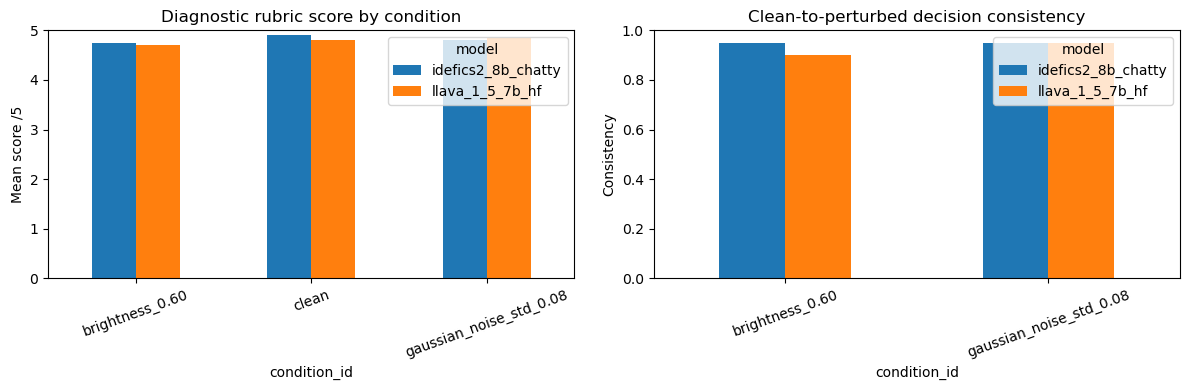

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pivot = condition_df.pivot(index='condition_id', columns='model', values='mean_total_score')
pivot.plot.bar(ax=axes[0], ylim=(0, 5), title='Diagnostic rubric score by condition')
axes[0].set_ylabel('Mean score /5')
axes[0].tick_params(axis='x', rotation=20)

consistency = robustness_df.pivot(
    index='condition_id', columns='model', values='decision_consistency_clean_vs_perturbed'
)
consistency.plot.bar(ax=axes[1], ylim=(0, 1), title='Clean-to-perturbed decision consistency')
axes[1].set_ylabel('Consistency')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [4]:
efficiency_rows = []
for model in comparison['models']:
    p = model['performance']
    identity = model['identity']
    efficiency_rows.append({
        'model': model['model_key'],
        'architecture': identity['runner_architecture'],
        'precision': identity['precision'],
        'end_to_end_p50_ms': p['question_to_response_ms']['p50'],
        'end_to_end_p95_ms': p['question_to_response_ms']['p95'],
        'ttft_p50_ms': p['ttft_ms']['p50'],
        'output_tokens_per_second_p50': p['output_tokens_per_second']['p50'],
        'gpu_peak_gib': p['gpu_device_memory_used_peak_mib']['max'] / 1024,
        'model_load_peak_gib': identity['model_load_gpu_peak_mib'] / 1024,
    })

efficiency_df = pd.DataFrame(efficiency_rows)
display(efficiency_df)
display(pd.DataFrame([comparison['pairwise_clean_comparison']]))

,model,architecture,precision,end_to_end_p50_ms,end_to_end_p95_ms,ttft_p50_ms,output_tokens_per_second_p50,gpu_peak_gib,model_load_peak_gib
0,idefics2_8b_chatty,idefics2,bfloat16,6305.443754,7281.599973,768.809213,27.867155,18.232422,15.956055
1,llava_1_5_7b_hf,llava,float16,4386.536797,5966.578721,415.615173,22.679044,14.153320,13.465820


,0
0,"{'baseline_model_key': 'idefics2_8b_chatty', '..."


## Interpretation

- Idefics2 and LLaVA tie on 19 of 20 clean scenarios; the clean mean differs by 0.100/5.
- LLaVA is faster and uses less peak device memory in this controlled A40 run, while its median output-token throughput is lower.
- A negative clean-to-noise score drop is a review signal, not evidence that image corruption improves perception.
- The benchmark uses 20 public still images. It does not measure calibrated cameras, temporal fusion, product thresholds, identification, closed-loop control, or production readiness.